In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib as mpl
import itertools as it
import argparse as ap
import statannot
from statannotations.Annotator import Annotator
%cd /groups/pavri/bioinfo/max/TriC/contactBarplots

/groups/pavri/bioinfo/max/TriC/contactBarplots


In [2]:
%run contactBarplots_functions.py -i '../resource/sampleinfo_TriC17.tsv' -r '../resource/regions_of_interest_Ramos.tsv' \
	-r1 'start-G3ins' '3RRCBE2' '3RRCBE1' 'G3ins+-1kb' 'mu-4kb' -r2 '3RRCBE1' 'G3ins+-1kb' 'Ed+-2kb' 'mu-4kb' 'G3ins-end' \
	--prefix 'TRE3Gg3' --dir '../TriCplots/TriC17_mapq30' --capture '5Smu_capture' --genome 'hg38' --igh 105550000 105866000 --selfInt
tmp = contactsums['treatment_time'].values
contactsums['treatment_time'] = contactsums['replicate'].values
contactsums['replicate'] = tmp
contactsums

The interaction of region1 G3ins+-1kb with region2 3RRCBE1 was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 3RRCBE1 was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 G3ins+-1kb was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 Ed+-2kb was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 mu-4kb with region2 G3ins-end was not included because it is in wrong order. Please switch their places if the interaction should be included.
The interaction of region1 G3ins+-1kb with region2 3RRCBE1 was not included because it is in wrong order. Please switch their places if the interaction

,sample,replicate,treatment_time,region1,region2,pinteractions,regioncomb
0,TriC17_lane1_C9_TRE3Gg3,1,-Dox,start-G3ins,3RRCBE1,14.839072,start-G3ins - 3RRCBE1
1,TriC17_lane1_C9_TRE3Gg3,1,-Dox,start-G3ins,G3ins+-1kb,6.445130,start-G3ins - G3ins+-1kb
2,TriC17_lane1_C9_TRE3Gg3,1,-Dox,start-G3ins,Ed+-2kb,4.948365,start-G3ins - Ed+-2kb
3,TriC17_lane1_C9_TRE3Gg3,1,-Dox,start-G3ins,mu-4kb,33.562986,start-G3ins - mu-4kb
4,TriC17_lane1_C9_TRE3Gg3,1,-Dox,start-G3ins,G3ins-end,7.476021,start-G3ins - G3ins-end
...,...,...,...,...,...,...,...
155,TriC17_lane1_C17_TRE3Gg3,2,+Dox,G3ins+-1kb,G3ins+-1kb,432.953200,G3ins+-1kb - G3ins+-1kb
156,TriC17_lane1_C17_TRE3Gg3,2,+Dox,G3ins+-1kb,Ed+-2kb,0.000000,G3ins+-1kb - Ed+-2kb
157,TriC17_lane1_C17_TRE3Gg3,2,+Dox,G3ins+-1kb,mu-4kb,2.352667,G3ins+-1kb - mu-4kb
158,TriC17_lane1_C17_TRE3Gg3,2,+Dox,G3ins+-1kb,G3ins-end,11.516146,G3ins+-1kb - G3ins-end


In [3]:
region_order = ['3RRCBE1 - mu-4kb', '3RRCBE2 - mu-4kb', '3RRCBE1 - Ed+-2kb', '3RRCBE2 - Ed+-2kb', '3RRCBE2 - 3RRCBE1', 'G3ins+-1kb - G3ins-end', 'start-G3ins - G3ins+-1kb']

contactsumsSelf = contactsums.loc[contactsums['regioncomb'] == 'mu-4kb - mu-4kb'] # isolate zone 1
contactsums = contactsums.loc[contactsums['regioncomb'].isin(region_order)] # remove any self interaction zones

contactsums

,sample,replicate,treatment_time,region1,region2,pinteractions,regioncomb
1,TriC17_lane1_C9_TRE3Gg3,1,-Dox,start-G3ins,G3ins+-1kb,6.445130,start-G3ins - G3ins+-1kb
5,TriC17_lane1_C9_TRE3Gg3,1,-Dox,3RRCBE2,3RRCBE1,40.484267,3RRCBE2 - 3RRCBE1
7,TriC17_lane1_C9_TRE3Gg3,1,-Dox,3RRCBE2,Ed+-2kb,5.750400,3RRCBE2 - Ed+-2kb
8,TriC17_lane1_C9_TRE3Gg3,1,-Dox,3RRCBE2,mu-4kb,136.584333,3RRCBE2 - mu-4kb
12,TriC17_lane1_C9_TRE3Gg3,1,-Dox,3RRCBE1,Ed+-2kb,17.581467,3RRCBE1 - Ed+-2kb
13,TriC17_lane1_C9_TRE3Gg3,1,-Dox,3RRCBE1,mu-4kb,7.468444,3RRCBE1 - mu-4kb
18,TriC17_lane1_C9_TRE3Gg3,1,-Dox,G3ins+-1kb,G3ins-end,10.260780,G3ins+-1kb - G3ins-end
21,TriC17_lane1_C9_TRE3Gg3,1,+Dox,start-G3ins,G3ins+-1kb,19.124417,start-G3ins - G3ins+-1kb
25,TriC17_lane1_C9_TRE3Gg3,1,+Dox,3RRCBE2,3RRCBE1,24.016133,3RRCBE2 - 3RRCBE1
27,TriC17_lane1_C9_TRE3Gg3,1,+Dox,3RRCBE2,Ed+-2kb,0.000000,3RRCBE2 - Ed+-2kb


mu-4kb - mu-4kb_-Dox vs. mu-4kb - mu-4kb_+Dox: t-test independent samples with Benjamini-Hochberg correction, P_val:2.706e-01 t=1.213e+00
3RRCBE2 - mu-4kb_-Dox vs. 3RRCBE2 - mu-4kb_+Dox: t-test independent samples with Benjamini-Hochberg correction, P_val:1.390e-01 t=1.705e+00
3RRCBE1 - mu-4kb_-Dox vs. 3RRCBE1 - mu-4kb_+Dox: t-test independent samples with Benjamini-Hochberg correction, P_val:7.129e-01 t=-3.859e-01
3RRCBE1 - Ed+-2kb_-Dox vs. 3RRCBE1 - Ed+-2kb_+Dox: t-test independent samples with Benjamini-Hochberg correction, P_val:9.198e-01 t=1.050e-01
start-G3ins - G3ins+-1kb_-Dox vs. start-G3ins - G3ins+-1kb_+Dox: t-test independent samples with Benjamini-Hochberg correction, P_val:2.013e-01 t=-1.435e+00
3RRCBE2 - 3RRCBE1_-Dox vs. 3RRCBE2 - 3RRCBE1_+Dox: t-test independent samples with Benjamini-Hochberg correction, P_val:2.234e-01 t=1.358e+00
3RRCBE2 - Ed+-2kb_-Dox vs. 3RRCBE2 - Ed+-2kb_+Dox: t-test independent samples with Benjamini-Hochberg correction, P_val:2.722e-01 t=-1.209e+

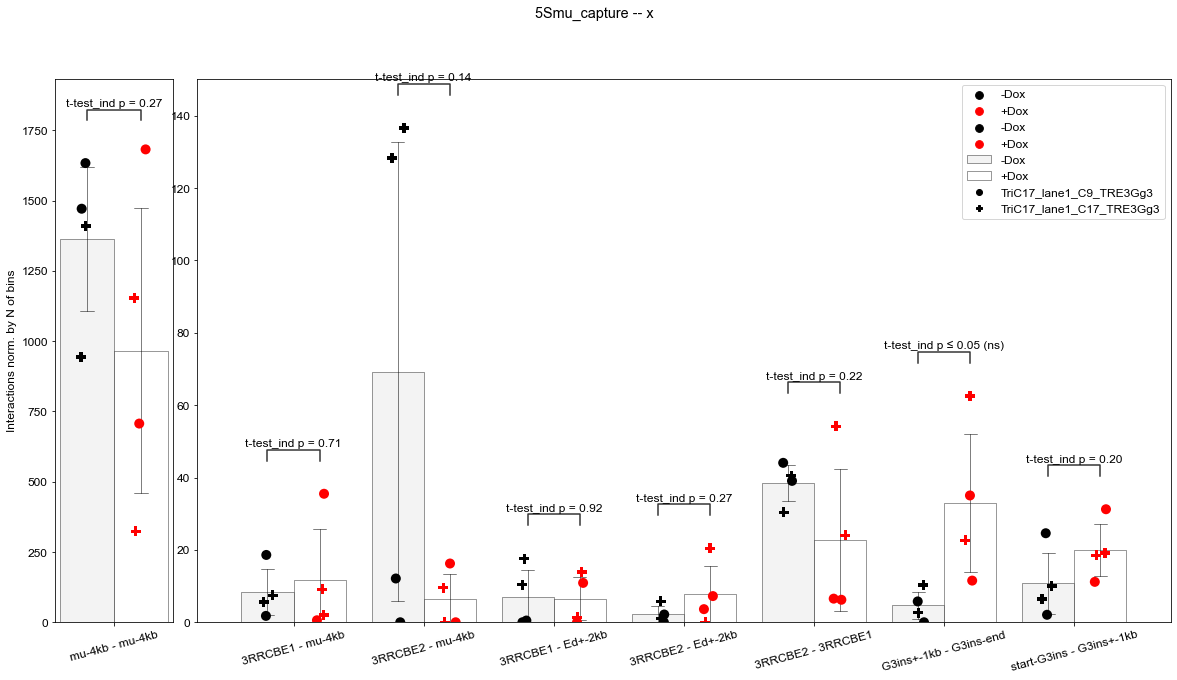

In [4]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5


fig = plt.figure(figsize=(20,10))
maxInteraction = max(contactsums['pinteractions'])
maxInteraction = maxInteraction + maxInteraction/10

markerlist = ['o', 'P', 'X', '*']

ax1 = fig.add_subplot(1, 8, 1)
sns.barplot(data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax1)
markerCounter = 0
for (sampleName, group2) in contactsumsSelf.groupby('sample'):
	sns.stripplot(data=group2, x='regioncomb', y='pinteractions', hue='treatment_time', marker=markerlist[markerCounter], ax=ax1, dodge=True, size=10,
		palette=['black', 'red'])
	markerCounter +=1

boxlist = [] # list with pairs for statistical significance test
for reg in contactsumsSelf['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsumsSelf['treatment_time'].unique()[0]), (reg, contactsumsSelf['treatment_time'].unique()[1]))]
annot = Annotator(ax1, data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', pairs=boxlist)
annot.configure(test='t-test_ind', text_format='simple', verbose=5, comparisons_correction="BH") #
annot.apply_and_annotate()

ax1.legend_.remove()
ax1.set_ylabel('Interactions norm. by N of bins')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15)



ax = fig.add_subplot(1, 8, (2, 8))
sns.barplot(data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax, order=region_order)
markerCounter = 0
for (sampleName, group2) in contactsums.groupby('sample'):
	sns.stripplot(data=group2, x='regioncomb', y='pinteractions', hue='treatment_time', marker=markerlist[markerCounter], ax=ax, dodge=True, size=10,
		palette=['black', 'red'], order=region_order)
	markerCounter +=1

boxlist = [] # list with pairs for statistical significance test
for reg in contactsums['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsums['treatment_time'].unique()[0]), (reg, contactsums['treatment_time'].unique()[1]))]
annot = Annotator(ax, data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', pairs=boxlist, order=region_order)
annot.configure(test='t-test_ind', text_format='simple', verbose=5, comparisons_correction="BH") #
annot.apply_and_annotate()

f = lambda m,c: plt.plot([],[],marker=m, color=c, ls="none")[0]
handles, labels = ax.get_legend_handles_labels()
handles += [f(list(dict.fromkeys(markerlist))[i], "k") for i in range(len(dict.fromkeys(markerlist)))]
labels += list(contactsums['sample'].unique())
ax.legend(handles, labels)
ax.set_ylim(0, maxInteraction)
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
fig.suptitle(f"5Smu_capture -- x")

fig.savefig('../plots/TriC17/TriC17_RamosTRE3Gg3_RegOfInterest_markers.pdf')

mu-4kb - mu-4kb_-Dox v.s. mu-4kb - mu-4kb_+Dox: t-test independent samples with Bonferroni correction, P_val=2.706e-01 stat=1.213e+00
3RRCBE2 - mu-4kb_-Dox v.s. 3RRCBE2 - mu-4kb_+Dox: t-test independent samples with Bonferroni correction, P_val=9.729e-01 stat=1.705e+00
3RRCBE1 - mu-4kb_-Dox v.s. 3RRCBE1 - mu-4kb_+Dox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=-3.859e-01
3RRCBE1 - Ed+-2kb_-Dox v.s. 3RRCBE1 - Ed+-2kb_+Dox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=1.050e-01
start-G3ins - G3ins+-1kb_-Dox v.s. start-G3ins - G3ins+-1kb_+Dox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=-1.435e+00
3RRCBE2 - 3RRCBE1_-Dox v.s. 3RRCBE2 - 3RRCBE1_+Dox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=1.358e+00
3RRCBE2 - Ed+-2kb_-Dox v.s. 3RRCBE2 - Ed+-2kb_+Dox: t-test independent samples with Bonferroni correction, P_val=1.000e+00 stat=-1.209e+00
G3ins+-1kb - G3ins-end_-D

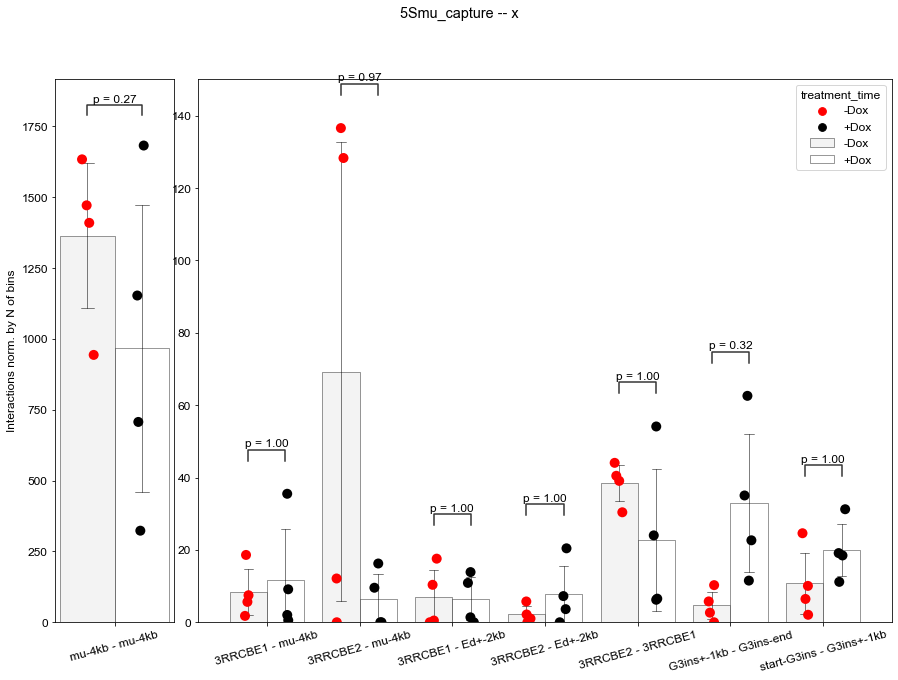

In [5]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5


fig = plt.figure(figsize=(15,10))
maxInteraction = max(contactsums['pinteractions'])
maxInteraction = maxInteraction + maxInteraction/10

markerlist = ['o', 'P', 'X', '*']

ax1 = fig.add_subplot(1, 6, 1)
sns.barplot(data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax1)
sns.stripplot(data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', ax=ax1, dodge=True, size=10,
	palette=['red', 'black'])

boxlist = [] # list with pairs for statistical significance test
for reg in contactsumsSelf['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsumsSelf['treatment_time'].unique()[0]), (reg, contactsumsSelf['treatment_time'].unique()[1]))]
statannot.add_stat_annotation(ax1, data=contactsumsSelf, x='regioncomb', y='pinteractions', hue='treatment_time', box_pairs=boxlist, test='t-test_ind', text_format='simple', verbose=2)

ax1.legend_.remove()
ax1.set_ylabel('Interactions norm. by N of bins')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15)



ax = fig.add_subplot(1, 6, (2, 6))
sns.barplot(data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', ci='sd', color='white', linewidth=0.5, edgecolor='black', 
	errcolor='black', errwidth=0.5, capsize=0.1, alpha=0.8, ax=ax, order=region_order)
sns.stripplot(data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', ax=ax, dodge=True, size=10,
	palette=['red', 'black'], order=region_order)

boxlist = [] # list with pairs for statistical significance test
for reg in contactsums['regioncomb'].unique():
	boxlist = boxlist + [((reg, contactsums['treatment_time'].unique()[0]), (reg, contactsums['treatment_time'].unique()[1]))]
statannot.add_stat_annotation(ax, data=contactsums, x='regioncomb', y='pinteractions', hue='treatment_time', box_pairs=boxlist, order=region_order, test='t-test_ind', text_format='simple', verbose=2)

ax.set_ylim(0, maxInteraction)
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
fig.suptitle(f"5Smu_capture -- x")

fig.savefig('../plots/TriC17/TriC17_RamosTRE3GG3_RegOfInterest.pdf')